In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Device: cpu
Xseq (14165, 45, 51) | Xflat (14165, 2295) | subjek 41
distribusi: {'background': 3113, 'reach': 1666, 'retract': 1812, 'hand_in_shelf': 1209, 'inspect_product': 2709, 'inspect_shelf': 3656}

=== FOLD 0 | train 11341 / val 2824 (subjek val: 9) ===
  Majority     : macroF1 0.072 | bal_acc 0.167
  RandomForest : macroF1 0.447 | bal_acc 0.436
  MLP          : macroF1 0.494 | bal_acc 0.495
  1D-CNN       : macroF1 0.469 | bal_acc 0.478
  TCN          : macroF1 0.530 | bal_acc 0.559

=== FOLD 1 | train 10433 / val 3732 (subjek val: 10) ===
  Majority     : macroF1 0.060 | bal_acc 0.167
  RandomForest : macroF1 0.437 | bal_acc 0.431
  MLP          : macroF1 0.461 | bal_acc 0.462
  1D-CNN       : macroF1 0.497 | bal_acc 0.499
  TCN          : macroF1 0.548 | bal_acc 0.552

=== FOLD 2 | train 11963 / val 2202 (subjek val: 7) ===
  Majority     : macroF1 0.070 | bal_acc 0.167
  RandomForest : macroF1 0.448 | bal_acc 0.445
  MLP          : macroF1 0.499 | bal_acc 0.513
  1D-CNN      

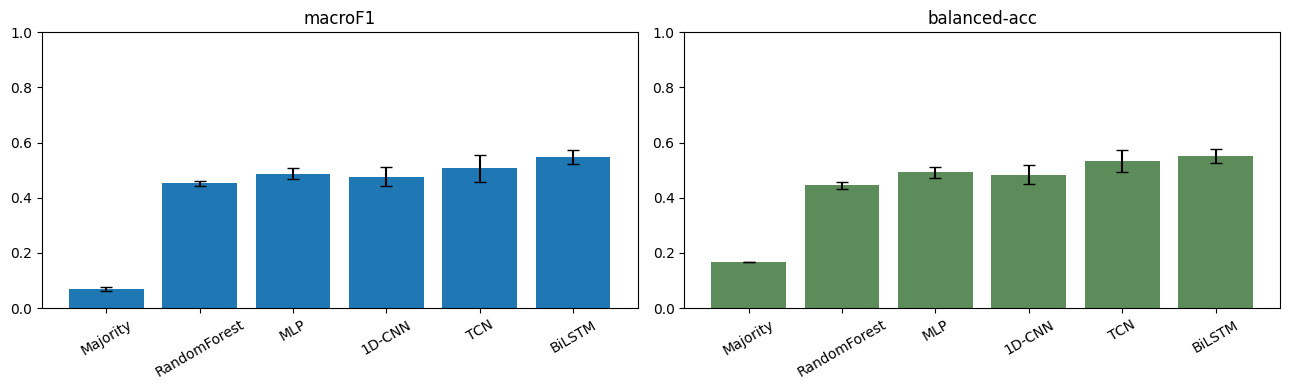


Tersimpan: interaction_comparison_table.csv, interaction_comparison_summary.json, interaction_comparison.png


In [ ]:
# ============================================================================
#  SAPA — PEMBANDING "KEPALA INTERAKSI": Majority + RandomForest + MLP + 1D-CNN + TCN
#  CV & split IDENTIK train_interaction.py (SEED sama, by-subjek) -> perbandingan ADIL.
# ----------------------------------------------------------------------------
#  Input : merl.npz  (keypoints [N,45,17,3], labels 0..5)
#     0=background 1=reach 2=retract 3=hand_in_shelf 4=inspect_product 5=inspect_shelf
#  Beda dari versi fall: 17 sendi + 3 channel (x,y,conf), 6 kelas, split BY SUBJEK.
#  CELL terakhir MENGGABUNGKAN dgn BiLSTM (interaction_cv_summary.json) -> tabel penuh.
#  Output: interaction_baselines_* + interaction_comparison_table/summary/png
#  Copy tiap "# ===== CELL N =====" ke satu cell Colab. GPU disarankan (RF pakai CPU).
# ============================================================================


# ===== CELL 1: Import + Konfigurasi =====
import os, json, numpy as np
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             recall_score, matthews_corrcoef, cohen_kappa_score)
import pandas as pd
import matplotlib.pyplot as plt

BASE      = "/content/drive/MyDrive/Belajar AI/Compfest/Dataset"
NPZ_PATH  = f"{BASE}/preprocessed_2/merl.npz"
MODEL_DIR = f"{BASE}/models"; os.makedirs(MODEL_DIR, exist_ok=True)

JOINTS = list(range(17)); USE_CHANNELS = 3
CLASS_NAMES = ["background", "reach", "retract", "hand_in_shelf", "inspect_product", "inspect_shelf"]
N_CLASSES = 6; INSPECT_IDX = [4, 5]
METRIC_COLS = ["acc", "bal_acc", "macroF1", "weightedF1", "mcc", "kappa"]   # cocok dgn BiLSTM summary
SEED, BATCH, EPOCHS, PATIENCE, N_FOLDS = 42, 128, 40, 8, 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED); np.random.seed(SEED)
print("Device:", DEVICE)


# ===== CELL 2: Load data + slice + grup subjek =====
d = np.load(NPZ_PATH, allow_pickle=True)
kp = d["keypoints"]; y = d["labels"].astype(np.int64); meta = d["meta"].astype(str)
N = kp.shape[0]
Xseq  = kp[:, :, JOINTS, :USE_CHANNELS].reshape(N, kp.shape[1], -1).astype(np.float32)   # [N,45,51]
Xflat = Xseq.reshape(N, -1)                                                              # [N,2295] utk RF
def subject(s): return s.split("_")[0]                                                   # '10_1' -> '10'
groups = np.array([subject(m) for m in meta])
print(f"Xseq {Xseq.shape} | Xflat {Xflat.shape} | subjek {len(set(groups))}")
print("distribusi:", {CLASS_NAMES[c]: int((y==c).sum()) for c in range(N_CLASSES)})


# ===== CELL 3: Model NN (MLP, 1D-CNN, TCN) + fungsi bantu =====
class MLP(nn.Module):
    def __init__(self, din, n):
        super().__init__(); self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(din, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, n))
    def forward(self, x): return self.net(x)

class CNN1D(nn.Module):
    def __init__(self, cin, n):
        super().__init__(); self.net = nn.Sequential(
            nn.Conv1d(cin, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n))
    def forward(self, x): return self.net(x.permute(0, 2, 1))

class Chomp1d(nn.Module):
    def __init__(self, c): super().__init__(); self.c = c
    def forward(self, x): return x[:, :, :-self.c].contiguous() if self.c > 0 else x
class TemporalBlock(nn.Module):
    def __init__(self, ci, co, k, dil, dropout=0.2):
        super().__init__(); pad = (k-1)*dil
        self.net = nn.Sequential(
            nn.Conv1d(ci, co, k, padding=pad, dilation=dil), Chomp1d(pad), nn.BatchNorm1d(co), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(co, co, k, padding=pad, dilation=dil), Chomp1d(pad), nn.BatchNorm1d(co), nn.ReLU(), nn.Dropout(dropout))
        self.down = nn.Conv1d(ci, co, 1) if ci != co else None; self.relu = nn.ReLU()
    def forward(self, x):
        out = self.net(x); res = x if self.down is None else self.down(x); return self.relu(out + res)
class TCN(nn.Module):
    def __init__(self, cin, n, channels=(64, 64, 128), k=5, dropout=0.2):
        super().__init__(); layers = []; prev = cin
        for i, ch in enumerate(channels): layers.append(TemporalBlock(prev, ch, k, 2**i, dropout)); prev = ch
        self.tcn = nn.Sequential(*layers); self.fc = nn.Linear(prev, n)
    def forward(self, x): return self.fc(self.tcn(x.permute(0, 2, 1)).mean(dim=2))

def full_metrics(yt, yp):
    return {"acc": accuracy_score(yt, yp), "bal_acc": balanced_accuracy_score(yt, yp),
            "macroF1": f1_score(yt, yp, average='macro', zero_division=0),
            "weightedF1": f1_score(yt, yp, average='weighted', zero_division=0),
            "mcc": matthews_corrcoef(yt, yp), "kappa": cohen_kappa_score(yt, yp)}

def train_torch(build_fn, tr, va):
    cnt = np.bincount(y[tr], minlength=N_CLASSES).astype(np.float32)
    cw = torch.tensor(cnt.sum() / (N_CLASSES * np.clip(cnt, 1, None)), device=DEVICE)
    model = build_fn().to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw); opt = torch.optim.Adam(model.parameters(), 1e-3, weight_decay=1e-4)
    dl = DataLoader(TensorDataset(torch.tensor(Xseq[tr]), torch.tensor(y[tr])),
                    batch_size=BATCH, shuffle=True, drop_last=True)
    Xva = torch.tensor(Xseq[va], device=DEVICE)
    best, wait, best_state = -1, 0, None
    for ep in range(EPOCHS):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
        model.eval()
        with torch.no_grad(): pv = model(Xva).argmax(1).cpu().numpy()
        f1 = f1_score(y[va], pv, average='macro', zero_division=0)
        if f1 > best: best, wait, best_state = f1, 0, {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= PATIENCE: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad(): return model(Xva).argmax(1).cpu().numpy()

def rf_fold(tr, va):
    return RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1,
                                  class_weight="balanced").fit(Xflat[tr], y[tr]).predict(Xflat[va])


# ===== CELL 4: 5-Fold CV (by-subjek) untuk 5 pembanding =====
MODELS = ["Majority", "RandomForest", "MLP", "1D-CNN", "TCN"]
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof = {m: -np.ones(N, np.int64) for m in MODELS}; rows = {m: [] for m in MODELS}
for fold, (tr, va) in enumerate(sgkf.split(Xflat, y, groups)):
    assert set(groups[tr]).isdisjoint(set(groups[va]))
    print(f"\n=== FOLD {fold} | train {len(tr)} / val {len(va)} (subjek val: {len(set(groups[va]))}) ===")
    preds = {
        "Majority":     np.full(len(va), int(np.bincount(y[tr]).argmax())),
        "RandomForest": rf_fold(tr, va),
        "MLP":          train_torch(lambda: MLP(Xseq.shape[1]*Xseq.shape[2], N_CLASSES), tr, va),
        "1D-CNN":       train_torch(lambda: CNN1D(Xseq.shape[2], N_CLASSES), tr, va),
        "TCN":          train_torch(lambda: TCN(Xseq.shape[2], N_CLASSES), tr, va),
    }
    for m in MODELS:
        oof[m][va] = preds[m]; rows[m].append({"fold": fold, **full_metrics(y[va], preds[m])})
        print(f"  {m:13s}: macroF1 {rows[m][-1]['macroF1']:.3f} | bal_acc {rows[m][-1]['bal_acc']:.3f}")


# ===== CELL 5: Ringkasan + GABUNG dgn BiLSTM -> tabel lengkap =====
def summ(mrows):
    df = pd.DataFrame(mrows)
    return {k: {"mean": round(float(df[k].mean()), 4), "std": round(float(df[k].std(ddof=0)), 4)} for k in METRIC_COLS}
all_summ = {m: summ(rows[m]) for m in MODELS}

bpath = f"{MODEL_DIR}/interaction_cv_summary.json"
if os.path.exists(bpath):
    all_summ["BiLSTM"] = json.load(open(bpath))["summary_mean_std"]
else:
    print(f"[info] BiLSTM belum ada ({os.path.basename(bpath)}) — jalankan Kepala_Interaksi dulu.")

order = [m for m in ["Majority", "RandomForest", "MLP", "1D-CNN", "TCN", "BiLSTM"] if m in all_summ]
tbl = pd.DataFrame({k: {m: f"{all_summ[m][k]['mean']:.3f} ± {all_summ[m][k]['std']:.3f}" for m in order}
                    for k in METRIC_COLS}).loc[order]
print("\n============== TABEL PERBANDINGAN KEPALA INTERAKSI ==============")
print(tbl.to_string())

# recall khusus aksi inspect (relevan Fitur A) per model
print("\nRecall aksi inspect (product+shelf) — OOF:")
for m in MODELS:
    r = recall_score(y, oof[m], labels=INSPECT_IDX, average='macro', zero_division=0)
    print(f"  {m:13s}: {r:.3f}")

pd.concat([pd.DataFrame(rows[m]).assign(model=m) for m in MODELS]).to_csv(
    f"{MODEL_DIR}/interaction_baselines_folds.csv", index=False)
tbl.to_csv(f"{MODEL_DIR}/interaction_comparison_table.csv")
with open(f"{MODEL_DIR}/interaction_comparison_summary.json", "w") as f:
    json.dump({m: all_summ[m] for m in order}, f, indent=2)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
mf = [all_summ[m]["macroF1"]["mean"] for m in order]; mfe = [all_summ[m]["macroF1"]["std"] for m in order]
ba = [all_summ[m]["bal_acc"]["mean"] for m in order]; bae = [all_summ[m]["bal_acc"]["std"] for m in order]
ax[0].bar(order, mf, yerr=mfe, capsize=4); ax[0].set_ylim(0,1); ax[0].set_title("macroF1"); ax[0].tick_params(axis='x', rotation=30)
ax[1].bar(order, ba, yerr=bae, capsize=4, color="#5b8c5a"); ax[1].set_ylim(0,1); ax[1].set_title("balanced-acc"); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(f"{MODEL_DIR}/interaction_comparison.png", dpi=120); plt.show()
print("\nTersimpan: interaction_comparison_table.csv, interaction_comparison_summary.json, interaction_comparison.png")